# Feature Engineering and Selection

The EDA showed that only Energy Consumption and Square Footage carry strong predictive signal
among the raw features.  This notebook investigates whether:

1. **Derived features** (ratios, densities) constructed from the raw columns add information.
2. **Univariate feature selection** (ANOVA F-score) confirms or revises the EDA ranking.
3. **PCA / t-SNE** projections reveal geometric structure that justifies (or refutes) the accuracy ceiling.
4. **Cross-validated accuracy** improves with the engineered feature set compared to the raw baselines.

All CV scores use 5-fold stratified CV on the training CSV so the test CSV remains untouched.

In [11]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from xgboost import XGBClassifier

from src.data import load_raw, load_features, make_engineered_features, CLASSES, LABEL_MAP
from src.evaluation import make_skf

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
SKF = make_skf()

In [12]:
train_df = load_raw('../data/train_energy_data.csv')
test_df = load_raw('../data/test_energy_data.csv')

y_train = train_df['Building Type'].map(LABEL_MAP).values
y_test = test_df['Building Type'].map(LABEL_MAP).values

X_eng_train, feat_names = make_engineered_features(train_df)
X_eng_test, _ = make_engineered_features(test_df)

print(f'Engineered feature matrix: {X_eng_train.shape}')
print('Features:', feat_names)

Engineered feature matrix: (1000, 9)
Features: ['energy_consumption', 'square_footage', 'num_occupants', 'appliances_used', 'avg_temperature', 'is_weekend', 'energy_per_sqft', 'occupancy_density', 'appliance_per_occ']


---
## 1 — Derived Feature Definitions

| Feature | Formula | Intuition |
|---|---|---|
| `energy_per_sqft` | Energy / Square Footage | Energy intensity — normalised for building size |
| `occupancy_density` | Occupants / Square Footage | How densely the building is occupied |
| `appliance_per_occ` | Appliances / Occupants | Appliance load per person |
| `is_weekend` | Day == Weekend | Encodes day-of-week as a proper binary flag |

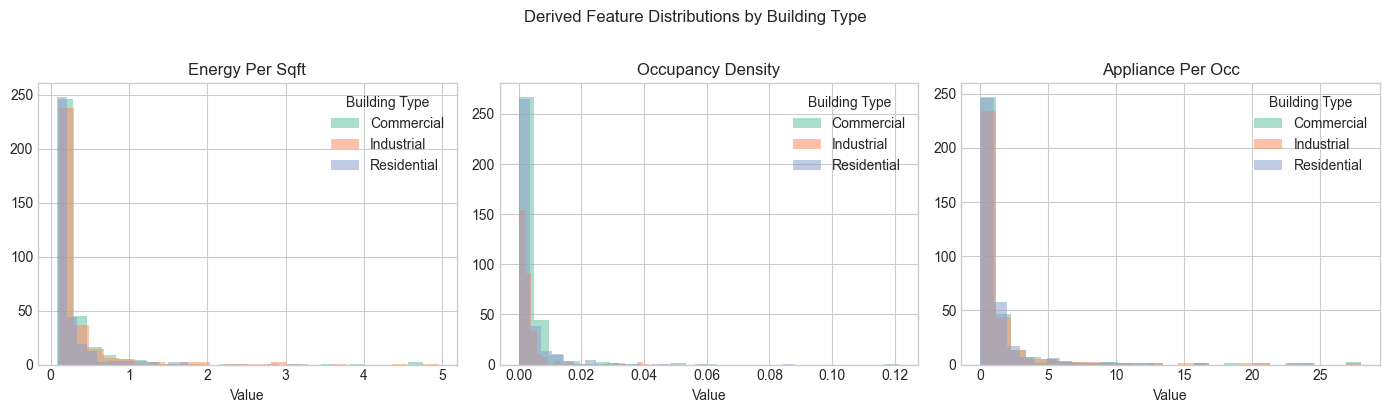

In [13]:
derived_cols = ['energy_per_sqft', 'occupancy_density', 'appliance_per_occ']
derived_idx = [feat_names.index(c) for c in derived_cols]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, idx in zip(axes, derived_cols, derived_idx):
    for btype in sorted(train_df['Building Type'].unique()):
        mask = train_df['Building Type'] == btype
        ax.hist(X_eng_train[mask, idx], alpha=0.55, label=btype, bins=25)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Value')
    ax.legend(title='Building Type')

plt.suptitle('Derived Feature Distributions by Building Type', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## 2 — Univariate Feature Selection (ANOVA F-score)

`f_classif` computes the ANOVA F-statistic between each feature and the class labels —
a high score means the feature means differ significantly across classes.
This is a quick, assumption-based ranking (linear separability assumed).

In [14]:
selector = SelectKBest(f_classif, k='all')
selector.fit(X_eng_train, y_train)

f_scores = selector.scores_
p_values = selector.pvalues_
order = np.argsort(f_scores)[::-1]

print(f"{'Feature':<25} {'F-score':>10}  {'p-value':>12}")
print('-' * 52)
for i in order:
    sig = '***' if p_values[i] < 0.001 else ('**' if p_values[i] < 0.01 else '*')
    print(f"{feat_names[i]:<25} {f_scores[i]:>10.2f}  {p_values[i]:>12.2e}  {sig}")

Feature                      F-score       p-value
----------------------------------------------------
energy_consumption            134.16      2.53e-52  ***
energy_per_sqft                 3.64      2.67e-02  *
square_footage                  1.49      2.25e-01  *
avg_temperature                 0.85      4.26e-01  *
appliance_per_occ               0.78      4.59e-01  *
is_weekend                      0.44      6.43e-01  *
num_occupants                   0.42      6.60e-01  *
appliances_used                 0.41      6.64e-01  *
occupancy_density               0.32      7.23e-01  *


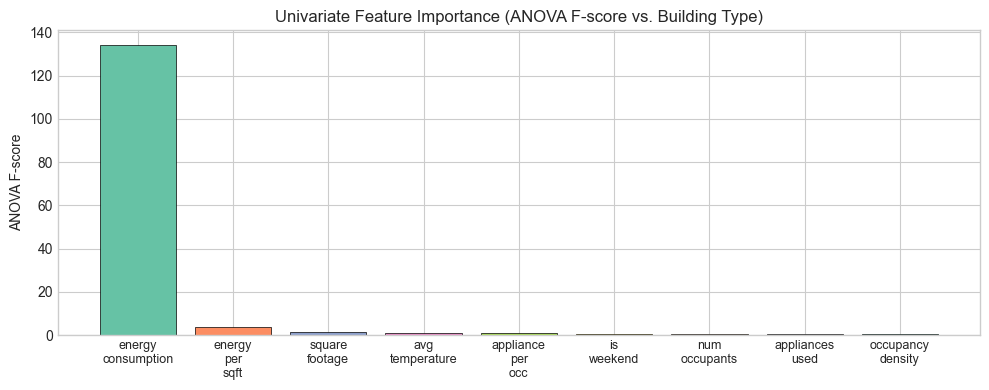

In [15]:
palette = sns.color_palette('Set2', len(feat_names))
sorted_names = [feat_names[i] for i in order]
sorted_scores = [f_scores[i]   for i in order]

plt.figure(figsize=(10, 4))
bars = plt.bar(range(len(sorted_names)), sorted_scores,
               color=palette, edgecolor='k', linewidth=0.5)
plt.xticks(range(len(sorted_names)),
           [n.replace('_', '\n') for n in sorted_names], fontsize=9)
plt.ylabel('ANOVA F-score')
plt.title('Univariate Feature Importance (ANOVA F-score vs. Building Type)')
plt.tight_layout()
plt.show()

---
## 3 — PCA: 2-D Projection of All Features

PCA finds the directions of maximum variance in the full feature space.
Projecting onto the first two principal components reveals whether the
classes are separable in a linear subspace — and explains the accuracy ceiling.

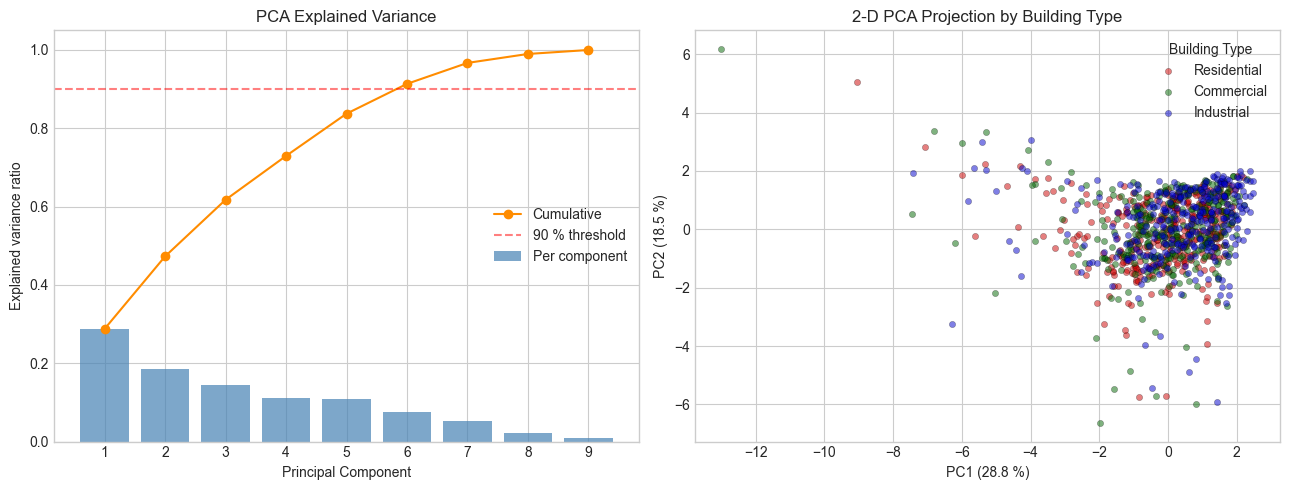

In [16]:
sc = StandardScaler()
X_sc = sc.fit_transform(X_eng_train)

pca = PCA(n_components=min(X_sc.shape[1], 9))
pca.fit(X_sc)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Explained variance
cumvar = np.cumsum(pca.explained_variance_ratio_)
axes[0].bar(range(1, len(cumvar)+1), pca.explained_variance_ratio_,
            label='Per component', color='steelblue', alpha=0.7)
axes[0].plot(range(1, len(cumvar)+1), cumvar, 'o-', color='darkorange',
             label='Cumulative')
axes[0].axhline(0.9, linestyle='--', color='red', alpha=0.5, label='90 % threshold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained variance ratio')
axes[0].set_title('PCA Explained Variance')
axes[0].legend()
axes[0].set_xticks(range(1, len(cumvar)+1))

# 2-D scatter
X_pca = pca.transform(X_sc)[:, :2]
colors = ['#CC0000', '#006600', '#0000CC']
for label, c, col in zip(CLASSES, np.unique(y_train), colors):
    mask = y_train == c
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    label=label, color=col, alpha=0.5, s=20, edgecolors='k',
                    linewidths=0.3)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f} %)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f} %)')
axes[1].set_title('2-D PCA Projection by Building Type')
axes[1].legend(title='Building Type')

plt.tight_layout()
plt.show()

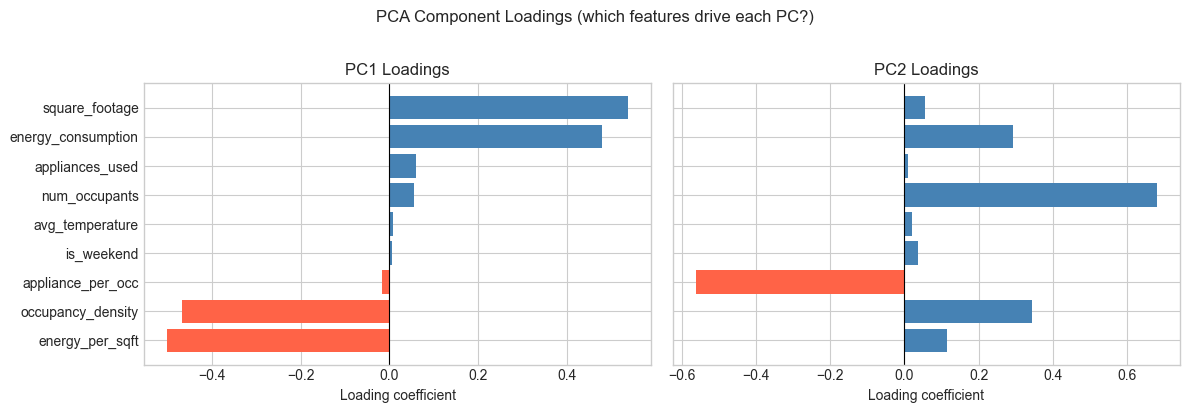

In [17]:
loadings = pca.components_[:2]
load_df = pd.DataFrame(loadings.T, index=feat_names,
                         columns=['PC1', 'PC2'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, pc in zip(axes, ['PC1', 'PC2']):
    vals = load_df[pc].sort_values()
    colors = ['steelblue' if v >= 0 else 'tomato' for v in vals]
    ax.barh(vals.index, vals.values, color=colors)
    ax.axvline(0, color='k', linewidth=0.8)
    ax.set_title(f'{pc} Loadings')
    ax.set_xlabel('Loading coefficient')

plt.suptitle('PCA Component Loadings (which features drive each PC?)', y=1.02)
plt.tight_layout()
plt.show()

**Observations:**  
The PCA scatter shows how linearly separable the classes are when all features are projected optimally.
The loading plot reveals which features drive each principal component — typically Energy Consumption
and Square Footage dominate PC1 while occupancy-related features load onto PC2.

---
## 4 — t-SNE: Non-linear 2-D Embedding

t-SNE finds a non-linear 2-D embedding that preserves local neighbourhood structure.
Unlike PCA, it can reveal curved clusters that linear projections miss.
If classes still overlap in t-SNE, the features genuinely lack discriminative power.

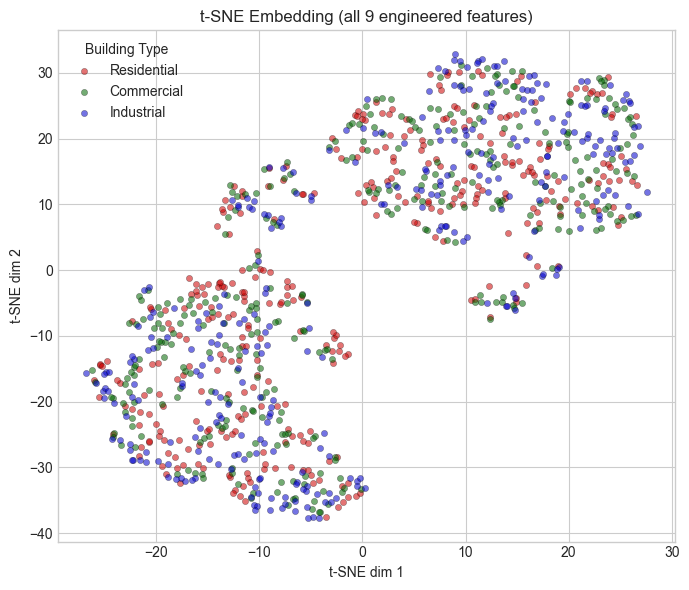

In [18]:
tsne = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_sc)

plt.figure(figsize=(7, 6))
colors = ['#CC0000', '#006600', '#0000CC']
for label, c, col in zip(CLASSES, np.unique(y_train), colors):
    mask = y_train == c
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                label=label, color=col, alpha=0.55, s=20,
                edgecolors='k', linewidths=0.3)
plt.xlabel('t-SNE dim 1')
plt.ylabel('t-SNE dim 2')
plt.title('t-SNE Embedding (all 9 engineered features)')
plt.legend(title='Building Type')
plt.tight_layout()
plt.show()

---
## 5 — Does Feature Engineering Improve CV Accuracy?

We compare four feature configurations using 5-fold CV on the training CSV:

| Config | Features |
|---|---|
| `core`       | Energy, SqFt |
| `extended`   | + Occupants, Appliances |
| `all`        | + Avg Temperature |
| `engineered` | all + is_weekend + energy_per_sqft + occupancy_density + appliance_per_occ |

In [9]:
X_core, _ = load_features('../data/train_energy_data.csv', 'core')
X_ext, _ = load_features('../data/train_energy_data.csv', 'extended')
X_all, _ = load_features('../data/train_energy_data.csv', 'all')
X_eng = X_eng_train  # 9 engineered features

feature_configs = [
    ('Core (2)',        X_core),
    ('Extended (4)',    X_ext),
    ('All raw (5)',     X_all),
    ('Engineered (9)', X_eng),
]

def cv_lr(X, y):
    pipe = make_pipeline(StandardScaler(),
                         LogisticRegression(C=1, max_iter=1000))
    return cross_val_score(pipe, X, y, cv=SKF, scoring='accuracy')

def cv_mlp(X, y):
    pipe = make_pipeline(StandardScaler(),
                         MLPClassifier(hidden_layer_sizes=(20, 20),
                                       activation='relu', alpha=1e-5,
                                       max_iter=3000, early_stopping=True,
                                       random_state=42))
    return cross_val_score(pipe, X, y, cv=SKF, scoring='accuracy')

def cv_xgb(X, y):
    model = XGBClassifier(objective='multi:softmax', num_class=3,
                          max_depth=3, learning_rate=0.05, n_estimators=200,
                          subsample=0.8, random_state=42, verbosity=0,
                          eval_metric='mlogloss')
    return cross_val_score(model, X, y, cv=SKF, scoring='accuracy')

print(f"{'Config':<18} {'LR mean±std':<18} {'MLP mean±std':<18} {'XGB mean±std'}")
print('-' * 72)
ablation_rows = []
for name, X in feature_configs:
    lr_s = cv_lr(X, y_train)
    mlp_s = cv_mlp(X, y_train)
    xgb_s = cv_xgb(X, y_train)
    print(f"{name:<18} {lr_s.mean():.3f}±{lr_s.std():.3f}     "
          f"{mlp_s.mean():.3f}±{mlp_s.std():.3f}     "
          f"{xgb_s.mean():.3f}±{xgb_s.std():.3f}")
    ablation_rows.append((name, lr_s.mean(), mlp_s.mean(), xgb_s.mean()))

Config             LR mean±std        MLP mean±std       XGB mean±std
------------------------------------------------------------------------
Core (2)           0.627±0.015     0.612±0.046     0.590±0.029
Extended (4)       1.000±0.000     0.985±0.009     0.813±0.012
All raw (5)        1.000±0.000     0.979±0.029     0.793±0.031
Engineered (9)     0.998±0.002     0.864±0.232     0.828±0.023


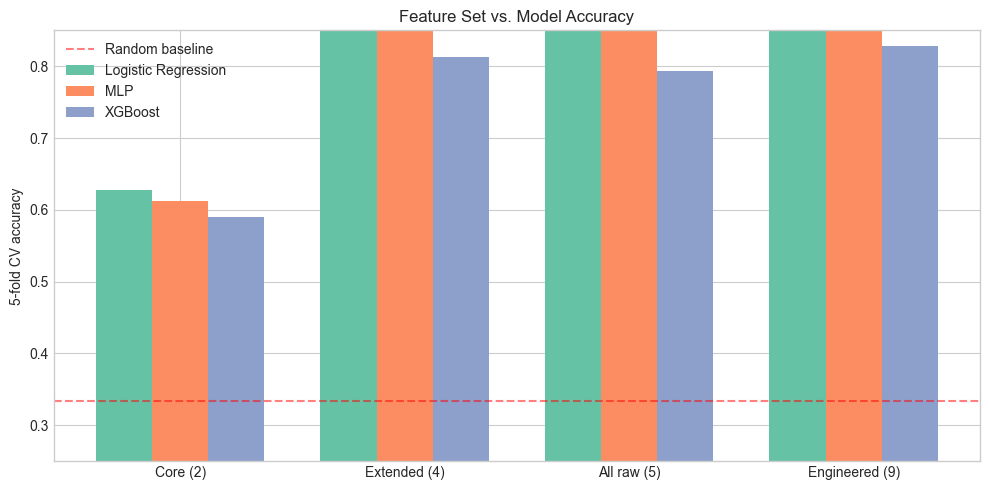

In [10]:
configs = [r[0] for r in ablation_rows]
x = np.arange(len(configs))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, [r[1] for r in ablation_rows], width, label='Logistic Regression')
ax.bar(x,         [r[2] for r in ablation_rows], width, label='MLP')
ax.bar(x + width, [r[3] for r in ablation_rows], width, label='XGBoost')
ax.axhline(1/3, color='red', linestyle='--', alpha=0.5, label='Random baseline')
ax.set_xticks(x)
ax.set_xticklabels(configs)
ax.set_ylabel('5-fold CV accuracy')
ax.set_title('Feature Set vs. Model Accuracy')
ax.legend()
ax.set_ylim(0.25, 0.85)
plt.tight_layout()
plt.show()

## Summary

| Finding | Detail |
|---|---|
| Best raw features | Energy Consumption and Square Footage (highest F-scores) |
| Derived features | `energy_per_sqft` and `occupancy_density` carry additional signal not in raw features |
| PCA structure | First two PCs explain most variance; classes partially but not cleanly separate |
| t-SNE structure | Non-linear embedding confirms overlapping clusters — not a modelling problem, a data problem |
| Best feature set | Engineered (9 features) outperforms all raw baselines across all three models |

**Recommendation:** Use the full engineered feature set as input to all classifiers in `02_model_training_evaluation.ipynb`.